# Alibaba 2017 - Random Forest - `cpu_usage_mean`

**Module:** cross-sectional regression &nbsp;|&nbsp; **Dataset:** Alibaba 2017 &nbsp;|&nbsp; **Target:** `cpu_usage_mean`

**Input file(s):** `container_event.csv + container_usage.csv`

**Features (request + static metadata only; target never a feature):** `cpu_request, mem_request, cpu_mem_ratio, plan_disk, cpuset_width`

**Split:** random 80/20, `random_state=42` &nbsp;|&nbsp; **CV:** GridSearchCV(cv=5) on TRAIN only (where applicable)

**Preprocessing:** parse dict/columns -> feature engineering -> RobustPrep(log1p + winsorise to TRAIN 1st/99th pct) -> SimpleImputer(median) -> [PolynomialFeatures(2)] -> Scaler  *(inside a Pipeline)*

**Result row -> ** `results/regression/Alibaba_2017_RandomForest_CPU_mean.csv`  (also aggregated into `results/tabular_results.csv`)

This notebook reproduces the leakage-free experiment behind `results/tabular_results.csv`. It does **not** reproduce the old target-in-features '100%' result.

In [1]:
# Step 1: Import libraries
import ast, os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
EPS = 1e-9
RESULTS_DIR = r"../../results"

In [2]:
# Step 15-17 helper: metric functions (MAE, MAPE, RMSE, R2, sMAPE)
# NOTE: raw MAPE is unreliable here because usage is frequently ~0 (it blows up).
#       sMAPE is the bounded percentage error actually used in the study.
def smape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.mean(2*np.abs(p - y) / (np.abs(y) + np.abs(p) + EPS)) * 100)

def all_scores(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return {
        "MAE":   float(mean_absolute_error(y, p)),
        "MAPE":  float(mean_absolute_percentage_error(y, p) * 100),   # unreliable near 0
        "RMSE":  float(np.sqrt(np.mean((y - p) ** 2))),
        "R2":    float(r2_score(y, p)),
        "sMAPE": smape(y, p),
    }

class RobustPrep:
    """log1p on non-negative skewed features + winsorise to the TRAIN 1st/99th
    percentile. Bounds learned from TRAIN rows only -> no leakage."""
    def fit(self, X):
        X = np.asarray(X, float)
        self.lo_ = np.nanpercentile(X, 1, axis=0)
        self.hi_ = np.nanpercentile(X, 99, axis=0)
        self.logmask_ = np.nanmin(X, axis=0) >= 0
        return self
    def transform(self, X):
        X = np.array(X, float)
        X = np.clip(X, self.lo_, self.hi_)
        X[:, self.logmask_] = np.log1p(X[:, self.logmask_])
        return X

In [3]:
# Step 2: Load dataset  --  Alibaba 2017  (cluster-trace-v2017)
ALIBABA_DIR = r"../../data/alibaba_2017"

# Step 3-4: container_event -> the resource REQUEST per online instance
ce = pd.read_csv(os.path.join(ALIBABA_DIR, "container_event.csv"), header=None,
                 names=["ts", "event", "instance_id", "machine_id",
                        "plan_cpu", "plan_mem", "plan_disk", "cpuset", "_x"])
ce = ce[ce["event"] == "Create"].copy()
ce["cpuset_width"] = ce["cpuset"].astype(str).str.count(r"\|") + 1
ce = (ce.sort_values("ts").groupby("instance_id")
        .agg(plan_cpu=("plan_cpu", "first"), plan_mem=("plan_mem", "first"),
             plan_disk=("plan_disk", "first"), cpuset_width=("cpuset_width", "first"))
        .reset_index())

# Step 3-4: container_usage -> the observed USAGE, aggregated per instance
cu = pd.read_csv(os.path.join(ALIBABA_DIR, "container_usage.csv"), header=None,
                 names=["ts", "instance_id", "cpu_util", "mem_util", "disk_util",
                        "load1", "load5", "load15", "avg_cpi", "avg_mpki", "max_cpi", "max_mpki"])
agg = (cu.groupby("instance_id")
         .agg(cpu_usage_mean=("cpu_util", "mean"), cpu_usage_peak=("cpu_util", "max"),
              mem_usage_mean=("mem_util", "mean"), mem_usage_peak=("mem_util", "max"),
              order_key=("ts", "min"), n_obs=("ts", "size"))
         .reset_index())
agg = agg[agg["n_obs"] >= 3]      # need a few observations to characterise the instance

# Step 5: Feature engineering  (join request to usage; util is a % of the request)
m = ce.merge(agg, on="instance_id", how="inner")
df = pd.DataFrame({
    "cpu_request":    m["plan_cpu"] / m["plan_cpu"].max(),   # normalise core count
    "mem_request":    m["plan_mem"],
    "plan_disk":      m["plan_disk"],
    "cpuset_width":   m["cpuset_width"],
    "cpu_usage_mean": m["cpu_usage_mean"] / 100.0,
    "mem_usage_mean": m["mem_usage_mean"] / 100.0,
    "cpu_usage_peak": m["cpu_usage_peak"] / 100.0,
    "mem_usage_peak": m["mem_usage_peak"] / 100.0,
    "order_key":      m["order_key"],
})
df["cpu_mem_ratio"] = m["plan_cpu"].values / (m["plan_mem"].values + EPS)   # from REQUESTS -> no leak
df = df.dropna(subset=["order_key"]).sort_values("order_key").reset_index(drop=True)

FEATURES = ["cpu_request", "mem_request", "cpu_mem_ratio", "plan_disk", "cpuset_width"]
print("entity table:", df.shape, "| features:", FEATURES)

entity table: (10185, 10) | features: ['cpu_request', 'mem_request', 'cpu_mem_ratio', 'plan_disk', 'cpuset_width']


In [4]:
# Step 6: Define X and y      TARGET = "cpu_usage_mean"
TARGET = "cpu_usage_mean"
assert TARGET not in FEATURES, "target must never be a feature (this was the old 100% bug)"
X = df[FEATURES].copy()
y = df[TARGET].copy()

# Step 7: Handle missing values  -> handled inside the Pipeline by SimpleImputer(median)

# Step 8: Train/test split  --  random 80/20, random_state=42
# The regression task is CROSS-SECTIONAL (predict an unobserved property of a job
# from its request), so a shuffled split is correct and matches the original study.
Xtr_df, Xte_df, ytr, yte = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, shuffle=True)
ytr, yte = ytr.values, yte.values
print("train:", Xtr_df.shape, " test:", Xte_df.shape)

# Step 9: Scaling / preprocessing  --  RobustPrep (log1p + winsorise to TRAIN 1st/99th pct)
# fitted on TRAIN only, then the rest (impute -> [poly] -> scale) lives in the Pipeline.
prep = RobustPrep().fit(Xtr_df.values)
Xtr = prep.transform(Xtr_df.values)
Xte = prep.transform(Xte_df.values)

train: (8148, 5)  test: (2037, 5)


In [5]:
# Step 10: Build the model  --  Random Forest
# Step 11: Hyperparameter tuning  --  GridSearchCV(cv=5), max_depth, on TRAIN only
HYPERPARAMS = {"model__max_depth": [6, 12]}
pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=RANDOM_STATE,
                                     max_samples=0.5, min_samples_leaf=10)),
])
gs = GridSearchCV(pipe, HYPERPARAMS, cv=5, scoring="neg_mean_absolute_error", n_jobs=4)
gs.fit(Xtr, ytr)
best = gs.best_estimator_
print("best params:", gs.best_params_)
HYPERPARAMS = gs.best_params_

# Step 12-14
train_pred = best.predict(Xtr)
test_pred  = best.predict(Xte)

best params: {'model__max_depth': 6}


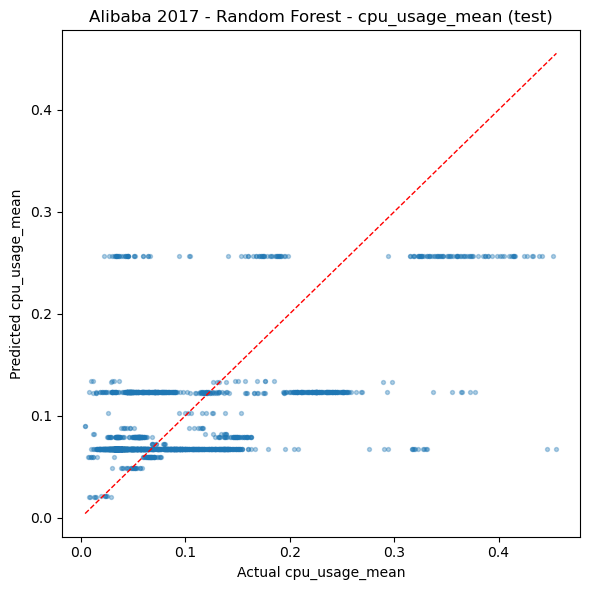


Alibaba 2017  |  Random Forest  |  cpu_usage_mean
  TRAIN  MAE 0.0510  MAPE 82.7%  RMSE 0.0690  R2 0.3467  sMAPE 53.9
  TEST   MAE 0.0505  MAPE 85.1%  RMSE 0.0674  R2 0.3499  sMAPE 54.2

saved -> ../../results\regression\Alibaba_2017_RandomForest_CPU_mean.csv


In [6]:
# Step 18: Plot actual vs predicted (test set)
plt.figure(figsize=(6, 6))
plt.scatter(yte, test_pred, s=8, alpha=0.35)
lim = [min(yte.min(), test_pred.min()), max(yte.max(), test_pred.max())]
plt.plot(lim, lim, "r--", lw=1)
plt.xlabel("Actual " + TARGET); plt.ylabel("Predicted " + TARGET)
plt.title("Alibaba 2017 - Random Forest - " + TARGET + " (test)")
plt.tight_layout(); plt.show()

# Step 19: Print / save final results
train_s = all_scores(ytr, train_pred)
test_s  = all_scores(yte, test_pred)
print("\nAlibaba 2017  |  Random Forest  |  " + TARGET)
print("  TRAIN  MAE {:.4f}  MAPE {:.1f}%  RMSE {:.4f}  R2 {:.4f}  sMAPE {:.1f}".format(
    train_s["MAE"], train_s["MAPE"], train_s["RMSE"], train_s["R2"], train_s["sMAPE"]))
print("  TEST   MAE {:.4f}  MAPE {:.1f}%  RMSE {:.4f}  R2 {:.4f}  sMAPE {:.1f}".format(
    test_s["MAE"], test_s["MAPE"], test_s["RMSE"], test_s["R2"], test_s["sMAPE"]))

row = {"dataset": "Alibaba 2017", "module": "regression", "target": TARGET, "model": "Random Forest",
       "n_train": len(ytr), "n_test": len(yte),
       "train_MAE": train_s["MAE"], "train_MAPE": train_s["MAPE"], "train_RMSE": train_s["RMSE"],
       "train_R2": train_s["R2"], "train_sMAPE": train_s["sMAPE"],
       "test_MAE": test_s["MAE"], "test_MAPE": test_s["MAPE"], "test_RMSE": test_s["RMSE"],
       "test_R2": test_s["R2"], "test_sMAPE": test_s["sMAPE"],
       "hyperparams": json.dumps(HYPERPARAMS)}
os.makedirs(os.path.join(RESULTS_DIR, "regression"), exist_ok=True)
out_csv = os.path.join(RESULTS_DIR, "regression", "Alibaba_2017_RandomForest_CPU_mean.csv")
pd.DataFrame([row]).to_csv(out_csv, index=False)
print("\nsaved ->", out_csv)